# Compare saved evaluation runs

Every `language-id eval` run is saved under `results/<model>_<dataset>_<timestamp>/` with its metrics, per-language scores, and plots. This notebook loads several of those **already-computed** runs back from disk and compares them side by side for post-evaluation analysis.

For example, this can be useful to answer: *given the same dataset / experiment setup, which model was best overall, and where does each one win or lose per language?*

Only runs on the **same dataset with the same per-language support** to provide a fair comparison.

## Setup

In [1]:
import matplotlib.pyplot as plt

%matplotlib inline

from language_id.compare_experiments import (
    RESULTS_ROOT,
    discover_runs,
    load_runs,
    check_comparable,
    overview_table,
    per_language_pivot,
    style_overview,
    style_per_language,
    plot_overview,
    plot_per_language_heatmap,
    plot_disagreement,
)

# Comparison figures from this notebook are written here.
FIG_DIR = RESULTS_ROOT / 'comparisons'
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Pick the runs to compare

`discover_runs()` lists every saved run id (newest first). Copy the ones you want into `RUN_IDS` below. They should share a dataset and experiment setup. Set `RUN_IDS = None` to load **all** saved runs instead.

In [2]:
for run_id in discover_runs():
    print(run_id)

nllb-lid_commonlid_20260602_T205544
nllb-lid_commonlid_20260602_T174731
nllb-lid_commonlid_20260602_T174304
nllb-lid_commonlid_20260602_T173559
nllb-lid_commonlid_20260602_T173214
nllb-lid_commonlid_20260602T152308Z
nllb-lid_commonlid_20260602T135341Z
nllb-lid_commonlid_20260601T172306Z
minimax-m27-1shot_commonlid_20260603_T004957
minimax-m27-0shot_commonlid_20260602_T224555
llama-5shot_commonlid_20260602T140702Z
llama-1shot_commonlid_20260602T140223Z
llama-0shot_commonlid_20260602T135816Z
langdetect_commonlid_20260602_T205505
langdetect_commonlid_20260602_T204754
langdetect_commonlid_20260602_T174649
langdetect_commonlid_20260602_T174223
langdetect_commonlid_20260602_T173514
langdetect_commonlid_20260602_T173134
langdetect_commonlid_20260602T152232Z
langdetect_commonlid_20260602T135324Z
langdetect_commonlid_20260601T174442Z
gpt-oss-20b_tetelancingo-nahuatl-4dd81077_20260602T124806Z
gpt-oss-120b-1shot_commonlid_20260602_T195943
gpt-oss-120b-0shot_commonlid_20260602_T190505
glotlid_tete

In [3]:
RUN_IDS = [
    'glotlid_commonlid_20260602_T205528',
    'langdetect_commonlid_20260602_T205505',
    'nllb-lid_commonlid_20260602_T205544',
    'gemma-0shot_commonlid_20260603_T063113',
    'gpt-oss-120b-0shot_commonlid_20260602_T190505',
    'gpt-oss-120b-1shot_commonlid_20260602_T195943',
    'minimax-m27-1shot_commonlid_20260603_T004957',
    'minimax-m27-0shot_commonlid_20260602_T224555',
]
# RUN_IDS = None  # uncomment to compare every saved run

runs = load_runs(RUN_IDS)
print(f'Loaded {len(runs)} runs:', ', '.join(r.label for r in runs))

# Sanity-check that these runs are directly comparable.
warnings = check_comparable(runs)
if warnings:
    print('\n⚠️  comparability warnings:')
    for w in warnings:
        print('  -', w)
else:
    print('✓ same dataset and per-language support — directly comparable')

Loaded 8 runs: glotlid, gpt-oss-120b-0shot, gpt-oss-120b-1shot, nllb-lid, minimax-m27-0shot, minimax-m27-1shot, gemma-0shot, langdetect
✓ same dataset and per-language support — directly comparable


## Overview: which model won?

One row per model, sorted by macro-F1 (best first). Greener is better.

In [4]:
table = overview_table(runs)
best = table.iloc[0]
print(f"Best overall: {best['model']}  (macro-F1 {best['macro_f1']:.3f}, accuracy {best['accuracy']:.3f})")
style_overview(table)
table.to_csv(FIG_DIR / 'overview.csv', index=False)

Best overall: glotlid  (macro-F1 0.702, accuracy 0.756)


saved /home/kostis/Projects/MDC/language-id/results/comparisons/overview.png


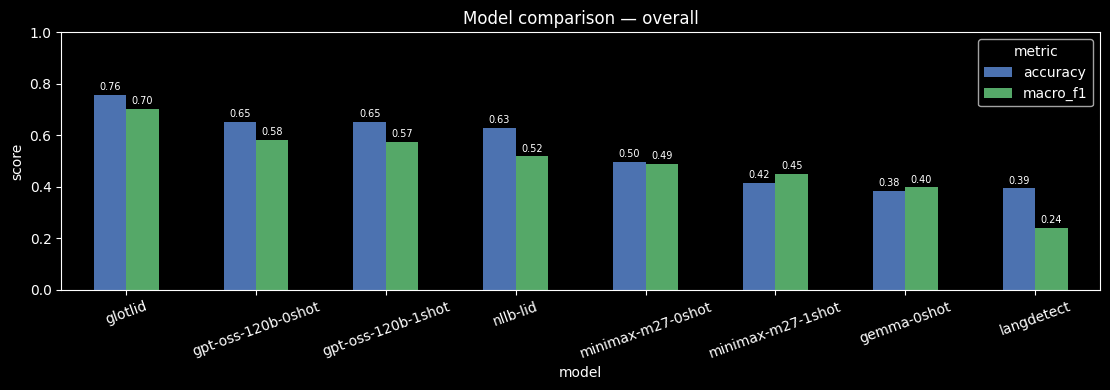

In [5]:
ax = plot_overview(runs)
plt.tight_layout()
fig_path = FIG_DIR / 'overview.png'
ax.figure.savefig(fig_path, dpi=150, bbox_inches='tight')
print('saved', fig_path)
plt.show()

## Per-language comparison

Per-language scores for every model, side by side. Languages are sorted by `support` (most-represented first). Switch `METRIC` to `'recall'` or `'precision'` to compare on a different axis.

In [6]:
f1 = 'f1'  # 'f1', 'recall', or 'precision'
recall = 'recall'
precision = 'precision'
METRIC = f1
pivot_f1 = per_language_pivot(runs, f1)
pivot_recall = per_language_pivot(runs, recall)
pivot_precision = per_language_pivot(runs, precision)

pivot_f1.to_csv(FIG_DIR / 'per_language_f1.csv')
pivot_recall.to_csv(FIG_DIR / 'per_language_recall.csv')
pivot_precision.to_csv(FIG_DIR / 'per_language_precision.csv')

style_per_language(pivot_f1)

,model,support,gemma-0shot,glotlid,gpt-oss-120b-0shot,gpt-oss-120b-1shot,langdetect,minimax-m27-0shot,minimax-m27-1shot,nllb-lid
name,lang,,,,,,,,,
Amharic,amh,200,0.77,0.96,0.96,0.99,0.00,0.84,0.67,0.96
Aragonese,arg,200,0.10,0.90,0.40,0.37,0.00,0.17,0.22,0.00
Arabic,ara,200,0.44,0.00,0.35,0.32,0.32,0.38,0.36,0.00
Ancient Hebrew,hbo,200,0.00,0.75,0.00,0.00,0.00,0.00,0.00,0.00
Bangla,ben,200,0.96,0.97,0.96,0.96,0.66,0.96,0.87,0.97
Bikol,bik,200,0.23,0.00,0.19,0.18,0.00,0.02,0.03,0.00
Assamese,asm,200,0.37,0.96,0.92,0.93,0.00,0.73,0.64,0.95
Crimean Tatar,crh,200,0.03,0.71,0.14,0.14,0.00,0.13,0.09,0.83
Central Bikol,bcl,200,0.01,0.65,0.02,0.02,0.00,0.02,0.03,0.00


### Per-language heatmap

saved /home/kostis/Projects/MDC/language-id/results/comparisons/per_language_f1_heatmap.png


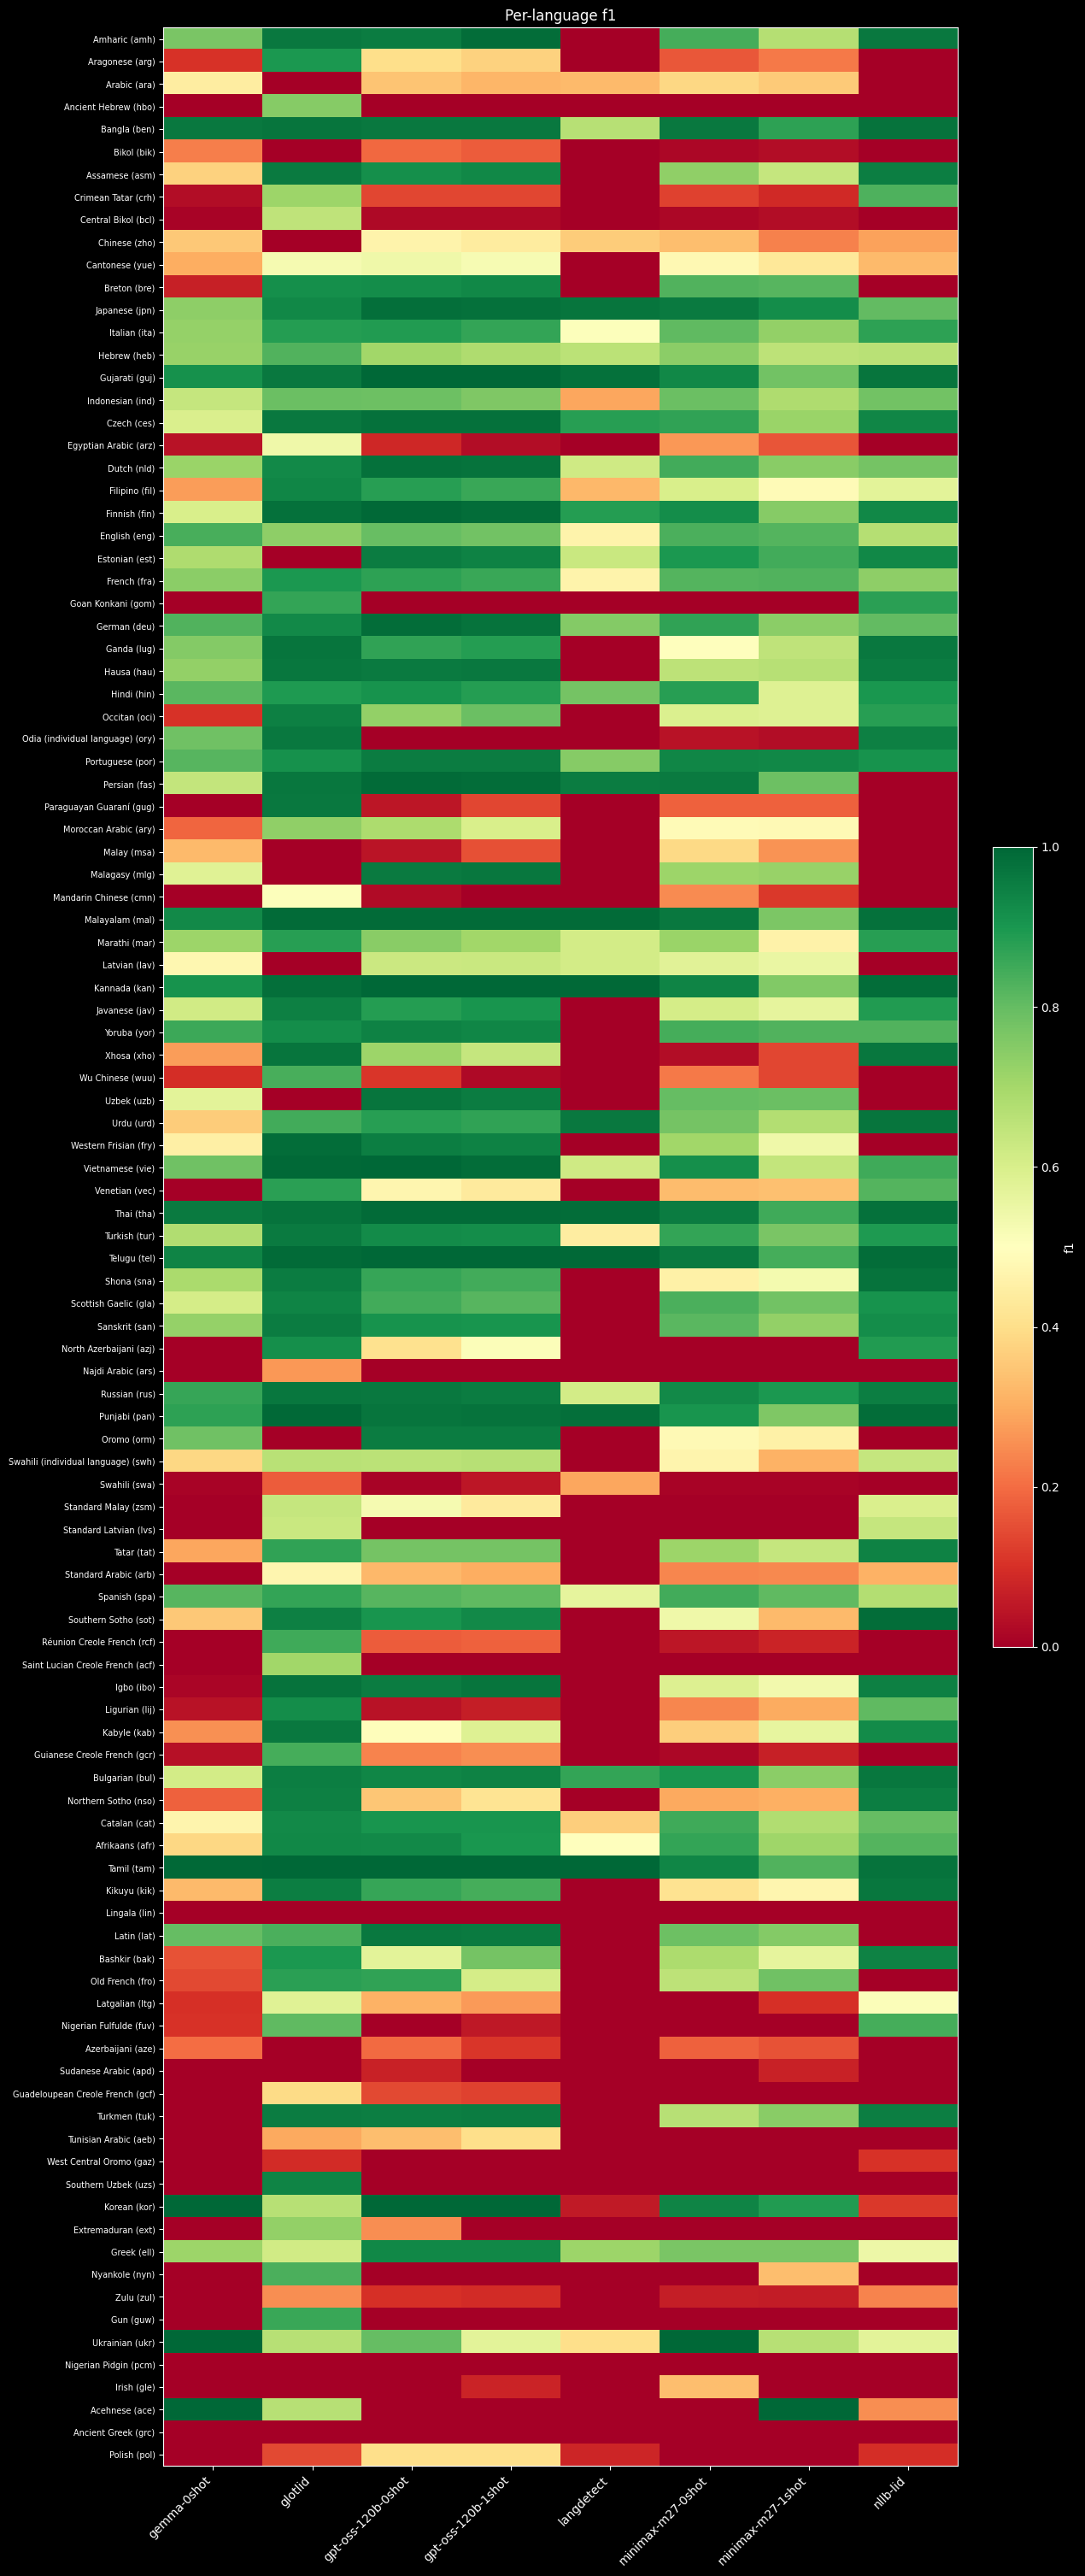

In [7]:
ax = plot_per_language_heatmap(runs, METRIC)
plt.tight_layout()
fig_path = FIG_DIR / f'per_language_{METRIC}_heatmap.png'
ax.figure.savefig(fig_path, dpi=150, bbox_inches='tight')
print('saved', fig_path)
plt.show()

### Where models disagree most

Languages with the largest best-minus-worst spread across models i.e. where the choice of model matters most.

saved /home/kostis/Projects/MDC/language-id/results/comparisons/disagreement_f1.png


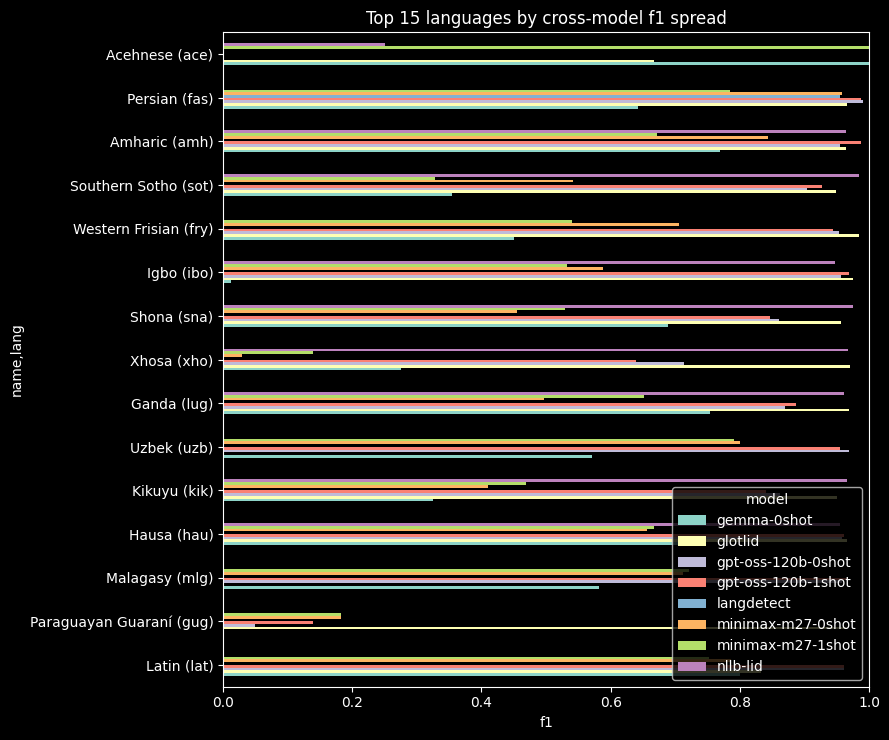

In [8]:
ax = plot_disagreement(runs, METRIC, top=15)
plt.tight_layout()
fig_path = FIG_DIR / f'disagreement_{METRIC}.png'
ax.figure.savefig(fig_path, dpi=150, bbox_inches='tight')
print('saved', fig_path)
plt.show()